# Pima Indians Diabetes Database

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)

sns.set(style='whitegrid')
%matplotlib inline

## 1. Load the Data

In [2]:
df = pd.read_csv('diabetes.csv')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Check for missing values (NaNs) and class balance
print('Missing values per column:')
print(df.isnull().sum())
print('\nOutcome value counts:')
print(df['Outcome'].value_counts())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Outcome value counts:
Outcome
0    500
1    268
Name: count, dtype: int64


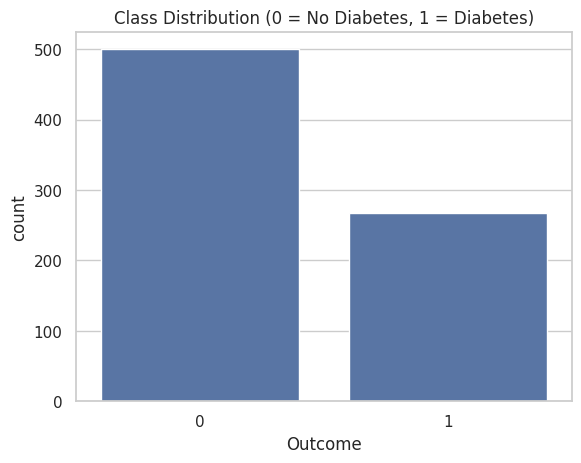

In [6]:
sns.countplot(x='Outcome', data=df)
plt.title('Class Distribution (0 = No Diabetes, 1 = Diabetes)')
plt.show()

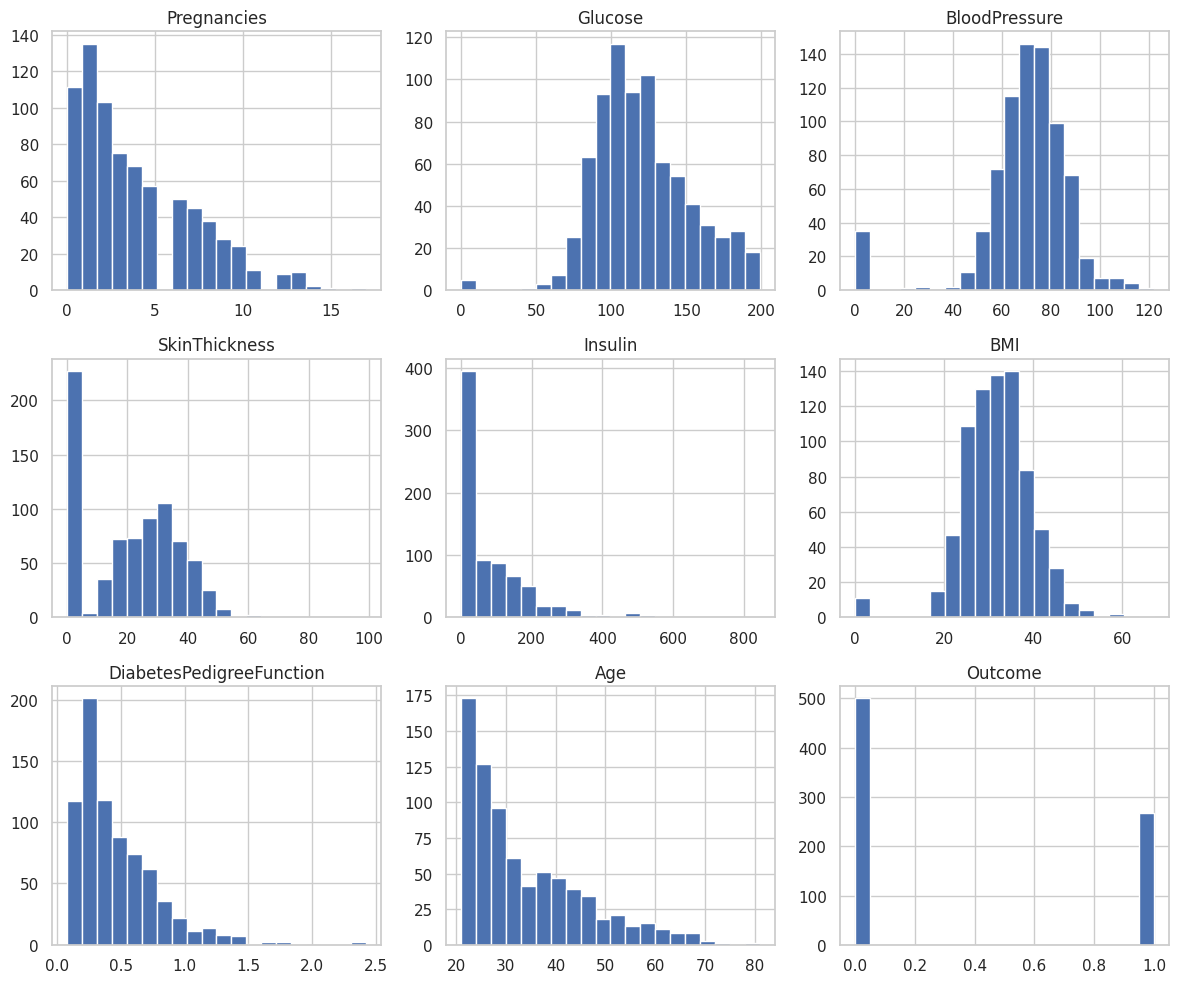

In [7]:
# Histograms for all numeric features
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

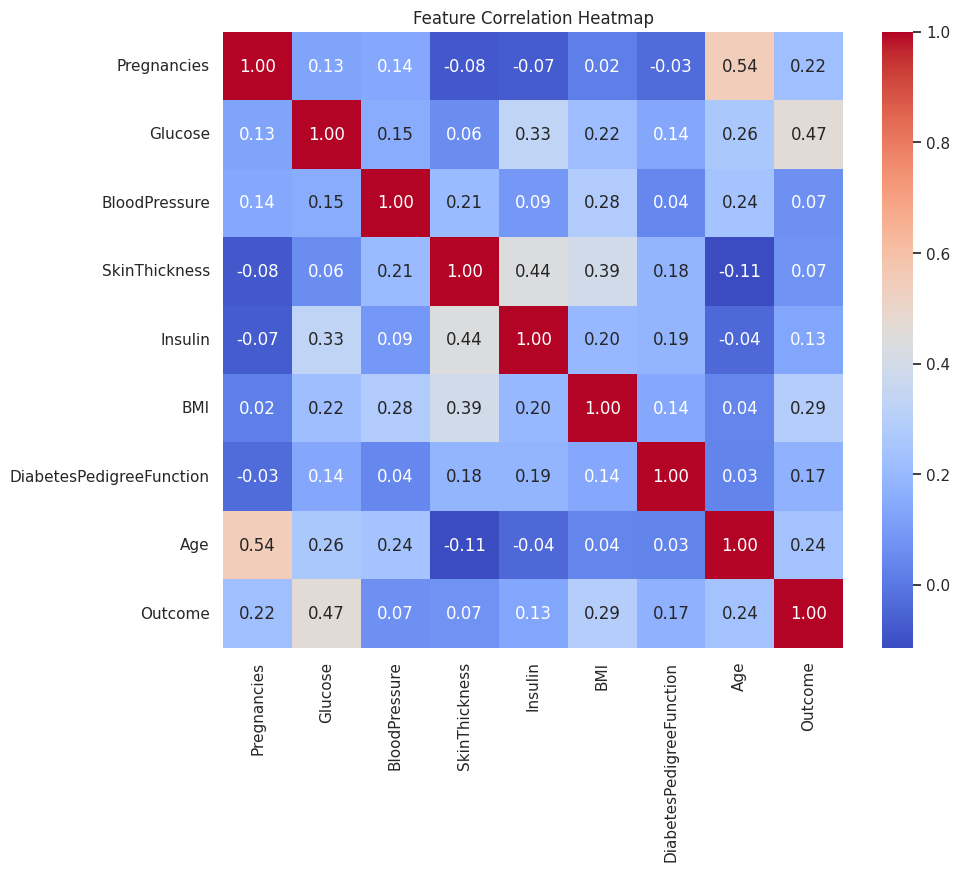

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

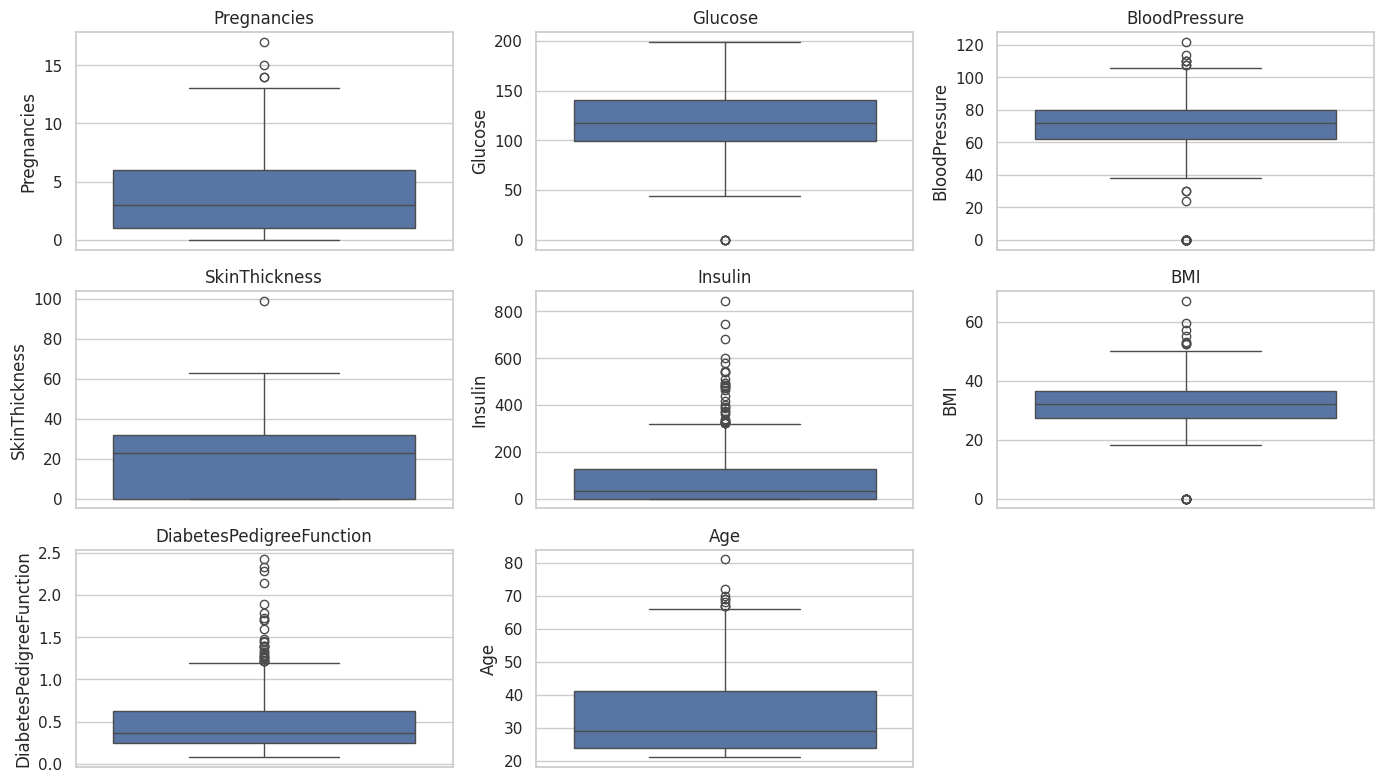

In [9]:
# Boxplots to spot outliers
plt.figure(figsize=(14, 8))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## 3. Data Cleaning
Several columns (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) contain **0** as a value, which is physiologically impossible and actually represents **missing data**. We'll replace these zeros with `NaN` and impute them using the median (grouped by `Outcome` to preserve class-specific distributions).

In [10]:
cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero counts before cleaning:')
print((df[cols_with_invalid_zeros] == 0).sum())

Zero counts before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [11]:
df_clean = df.copy()
df_clean[cols_with_invalid_zeros] = df_clean[cols_with_invalid_zeros].replace(0, np.nan)

print('Missing values after converting zeros to NaN:')
print(df_clean.isnull().sum())

Missing values after converting zeros to NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [12]:
# Impute missing values with the median, grouped by Outcome
for col in cols_with_invalid_zeros:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

print('Missing values after imputation:')
print(df_clean.isnull().sum())
df_clean.describe()

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
# Check for duplicate rows
print('Duplicate rows:', df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print('Shape after dropping duplicates:', df_clean.shape)

Duplicate rows: 0
Shape after dropping duplicates: (768, 9)


## 4. Train / Test Split & Feature Scaling
Random Forest doesn't strictly need scaling, but we keep it so the saved scaler can be reused consistently across models (and it's needed if we ever compare with distance-based models).

In [14]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape:', X_test_scaled.shape)

Train shape: (614, 8)
Test shape: (154, 8)


## 5. Random Forest Model Training
We tune `n_estimators`, `max_depth`, and `min_samples_leaf` via cross-validation.

In [15]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 8, 12],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print('Best params:', grid.best_params_)
print('Best CV accuracy: {:.4f}'.format(grid.best_score_))

Best params: {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV accuracy: 0.8843


In [16]:
rf = grid.best_estimator_

y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]

## 6. Evaluation of Results

In [17]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'ROC AUC  : {auc:.4f}')

Accuracy : 0.8701
Precision: 0.8269
Recall   : 0.7963
F1 Score : 0.8113
ROC AUC  : 0.9472


In [18]:
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.89      0.91      0.90       100
    Diabetes       0.83      0.80      0.81        54

    accuracy                           0.87       154
   macro avg       0.86      0.85      0.86       154
weighted avg       0.87      0.87      0.87       154



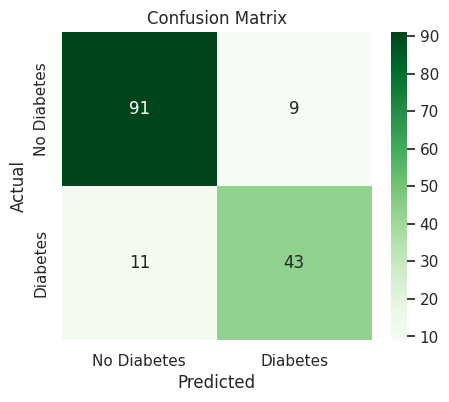

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

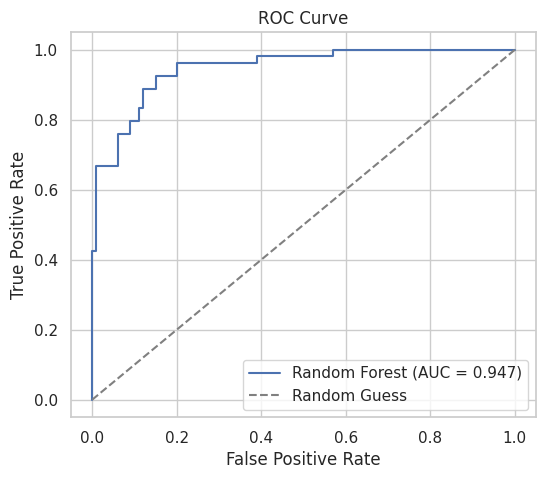

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

/tmp/ipykernel_536/1703113704.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


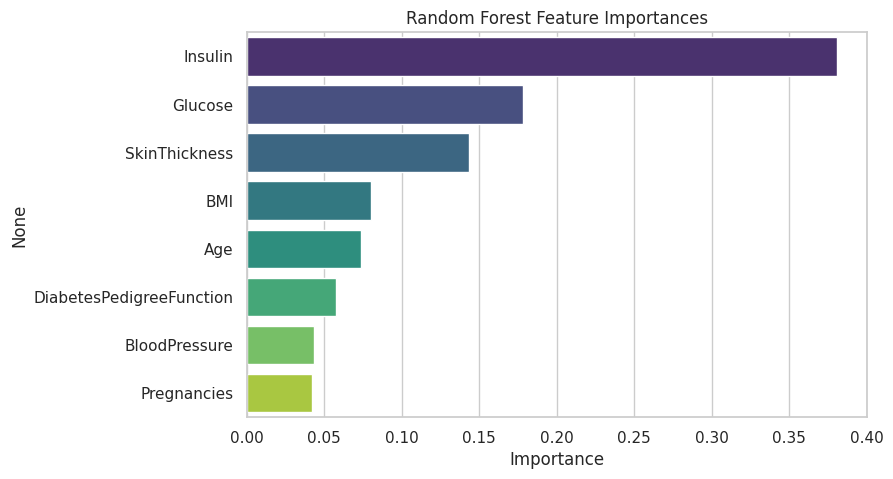

Insulin                     0.381086
Glucose                     0.178400
SkinThickness               0.143594
BMI                         0.080393
Age                         0.073481
DiabetesPedigreeFunction    0.057388
BloodPressure               0.043346
Pregnancies                 0.042312
dtype: float64

In [21]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.show()

importances

## 7. Save Model Artifacts
We save the trained Random Forest model and the fitted scaler so they can be loaded directly by the Streamlit dashboard, without retraining every time the app starts.

In [22]:
joblib.dump(rf, 'rf_diabetes_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(list(X.columns), 'feature_names.joblib')

print('Saved: rf_diabetes_model.joblib, scaler.joblib, feature_names.joblib')

Saved: rf_diabetes_model.joblib, scaler.joblib, feature_names.joblib


## 8. Summary
- Replaced biologically impossible **zero values** in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` with median imputation grouped by outcome.
- Scaled features with `StandardScaler`.
- Tuned Random Forest hyperparameters (`n_estimators`, `max_depth`, `min_samples_leaf`) via 5-fold cross-validation using `GridSearchCV`.
- Evaluated the final model using accuracy, precision, recall, F1, ROC-AUC, confusion matrix, ROC curve, and feature importances.
- Saved the model and scaler as `.joblib` files for reuse in the companion **Streamlit Diabetes Predictor** app.
